In [2]:
import pandas as pd
from pathlib import Path

df = pd.read_parquet(sorted(Path('../../storage/silver/apod').glob('apod_*.parquet'))[-1])
print(df[df['media_type'] == 'other'][['date', 'title', 'url', 'explanation']].to_string())

          date   title   url                                                                explanation
877 2024-10-23  Caught  None  Mechazilla has caught the Super Heavy booster! pic.twitter.com/6R5YatSVJX


In [3]:
# sanity check
print("Shape:", df.shape)
print("\nNulls:\n", df.isnull().sum())
print("\nMedia types:\n", df['media_type'].value_counts())
print("\nDate range:", df['date'].min(), "→", df['date'].max())

Shape: (1290, 8)

Nulls:
 hash_id          0
date             0
title            0
explanation      0
media_type       0
url              1
hdurl           83
copyright      447
dtype: int64

Media types:
 image    1207
video      82
other       1
Name: media_type, dtype: int64

Date range: 2021-06-12 00:00:00 → 2026-06-03 00:00:00


In [4]:
# word count — longer explanations are richer for RAG
df['word_count'] = df['explanation'].str.split().str.len()
df['word_count'].describe()

count    1290.000000
mean      149.996899
std        24.248647
min         8.000000
25%       135.000000
50%       150.000000
75%       164.000000
max       229.000000
Name: word_count, dtype: float64

In [5]:
# has image vs video vs other
df['has_image'] = df['media_type'] == 'image'

In [6]:
# year and month — useful for filtering
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

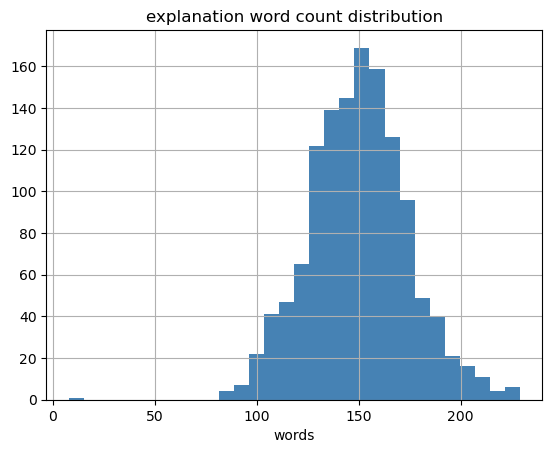

In [7]:
# explanation length distribution
import matplotlib.pyplot as plt
df['word_count'].hist(bins=30, color='steelblue')
plt.title('explanation word count distribution')
plt.xlabel('words')
plt.show()

In [8]:
# what are the shortest explanations? might be low quality for RAG
df.nsmallest(5, 'word_count')[['date', 'title', 'word_count', 'explanation']]


,date,title,word_count,explanation
877,2024-10-23,Caught,8,Mechazilla has caught the Super Heavy booster!...
189,2022-02-12,Aurora by Moonlight,85,The ice was singing as light from a bright gib...
582,2023-08-27,Three Galaxies and a Comet,86,Diffuse starlight and dark nebulae along the s...
893,2024-11-08,Helping Hand in Cassiopeia,86,Drifting near the plane of our Milky Way galax...
407,2023-02-09,Nacreous Clouds over Lapland,87,"Vivid and lustrous, wafting iridescent waves o..."


In [9]:
# what are the longest?
df.nlargest(5, 'word_count')[['date', 'title', 'word_count']]

,date,title,word_count
311,2022-09-18,Analemma over the Callanish Stones,229
617,2023-10-01,A Desert Eclipse,226
227,2022-05-01,First Horizon-Scale Image of a Black Hole,225
46,2021-08-05,Tycho and Clavius,222
103,2021-11-02,SN Requiem: A Supernova Seen Three Times So Far,222


In [10]:
# word count — longer explanations are richer for RAG
df['word_count'] = df['explanation'].str.split().str.len()
df['word_count'].describe()

count    1290.000000
mean      149.996899
std        24.248647
min         8.000000
25%       135.000000
50%       150.000000
75%       164.000000
max       229.000000
Name: word_count, dtype: float64

Decision for gold layer:

filter out entries with word_count < 50 — removes the Mechazilla entry and any other thin content
keep everything else — even 85 words is enough context for RAG

In [11]:
# gold enrichment
df_gold = df.copy()

# derived columns
df_gold['word_count'] = df_gold['explanation'].str.split().str.len()
df_gold['has_image'] = df_gold['media_type'] == 'image'
df_gold['year'] = df_gold['date'].dt.year
df_gold['month'] = df_gold['date'].dt.month

# filter thin content
before = len(df_gold)
df_gold = df_gold[df_gold['word_count'] >= 50]
print(f"Filtered {before - len(df_gold)} entries with < 50 words")

# RAG text field — combine title + explanation for richer embedding
df_gold['rag_text'] = df_gold['title'] + '. ' + df_gold['explanation']

# clean column order
cols = [
    'hash_id', 'date', 'year', 'month',
    'title', 'explanation', 'rag_text',
    'media_type', 'has_image',
    'word_count', 'url', 'hdurl', 'copyright'
]
df_gold = df_gold[cols]

print(f"Gold shape: {df_gold.shape}")
print(f"\nSample rag_text:")
print(df_gold['rag_text'].iloc[0][:200])

Filtered 1 entries with < 50 words
Gold shape: (1289, 13)

Sample rag_text:
Eclipse on the Water. clipses tend to come in pairs. Twice a year, during an eclipse season that lasts about 34 days, Sun, Moon, and Earth can nearly align. Then the full and new phases of the Moon se
